### Imports + Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

sns.set(style="whitegrid")

In [2]:
# Load processed dataset
df = pd.read_csv("../data/processed/nfhs_with_risk_scores.csv")

df.head()

,state,immunization,stunting,wasting,female_literacy,sanitation,risk_score,weighted_risk_score,risk_category
0,Andaman & Nicobar Islands,0.905535,0.093750,0.440954,0.653356,0.794189,1.181623,0.247159,Low
1,Andhra Pradesh,0.879240,0.420934,0.445026,0.133970,0.607864,2.244887,0.447020,Medium
2,Arunachal Pradesh,0.834217,0.301205,0.271670,0.295718,0.705637,1.737303,0.331808,Medium
3,Assam,0.842890,0.576431,0.774869,0.499132,0.456333,2.552945,0.558453,High
4,Bihar,0.867860,0.864458,0.842350,0.004630,0.123173,3.711145,0.768852,High


In [3]:
# Features
X = df[['immunization', 'stunting', 'wasting', 'female_literacy', 'sanitation']]

# Target
y = df['risk_category']

### Train Model

In [4]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X, y)

RandomForestClassifier(random_state=42)

In [5]:
rf_scores = cross_val_score(rf_model, X, y, cv=5)

print("Random Forest scores:", rf_scores)
print("Mean accuracy:", rf_scores.mean())

Random Forest scores: [0.875      0.85714286 1.         0.85714286 1.        ]
Mean accuracy: 0.9178571428571429


In [6]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_scores = cross_val_score(dt_model, X, y, cv=5)

print("Decision Tree scores:", dt_scores)
print("Mean accuracy:", dt_scores.mean())

Decision Tree scores: [0.75       1.         1.         0.85714286 0.85714286]
Mean accuracy: 0.8928571428571429


In [7]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

importance

,feature,importance
1,stunting,0.376240
2,wasting,0.346865
4,sanitation,0.105274
3,female_literacy,0.100087
0,immunization,0.071534


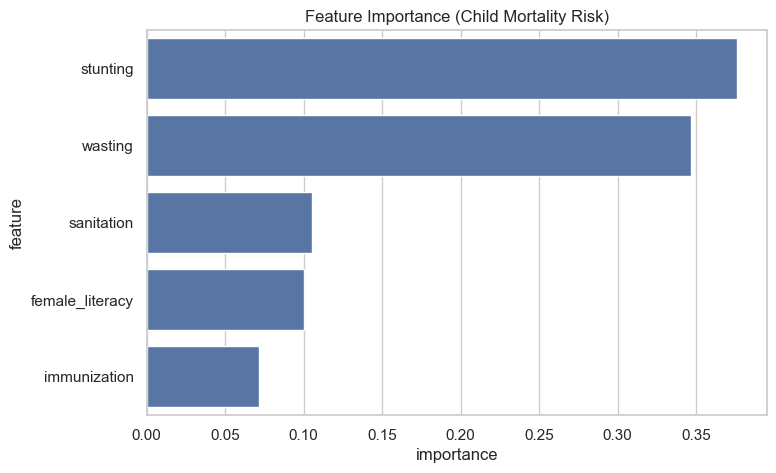

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='importance',
    y='feature'
)

plt.title("Feature Importance (Child Mortality Risk)")

plt.savefig("../outputs/figures/comparisons/nfhs_feature_importance_v2.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

In [10]:
import joblib

joblib.dump(rf_model, "../outputs/models/random_forest_model.pkl")

['../outputs/models/random_forest_model.pkl']